In [1]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
# sys.path.append('/home/mvargas/code/Huawei/survan')

from deep_lambda_cox import DeepLambdaSA
from lambda_cox import LambdaSA
from baseline_cox import SA

from utils import concordance_index, unroll_time, get_single_task_dataset, kaplan_meier, pad_to, get_single_target_and_mask
import yaml
import jax
import jax.numpy as jnp
import numpy as np
import haiku as hk
import matplotlib.pyplot as plt

In [2]:
config_path = '../configs/config_tasks.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [3]:
config['dataset_kwargs']['task_id'] = 4

In [4]:
task_id = config['dataset_kwargs']['task_id']
task_id

4

In [6]:
#Baseline SA with and wo landmarking
num_exps = 5
sizes = [.2]

ibs_is = np.zeros((num_exps, len(sizes)))
ibs_lm = np.zeros((num_exps, len(sizes)))

ci_is = np.zeros((num_exps, len(sizes)))
ci_lm = np.zeros((num_exps, len(sizes)))

for fold in range(num_exps):
    for i, size in enumerate(sizes):
        
        print(".", end="")
        
        # Initial state.
        config['landmark'] = False
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        ibs_is[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(seqs, q=0.0)
        ci_is[fold, i] = concordance_index(scores, ts, cs)

        # Landmarking.
        config['landmark'] = True
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        ms = test_gen.mask
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        ibs_lm[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(seqs, q=0.0)
        ci_lm[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.

100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:40<00:00,  1.61s/it]



.

100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:40<00:00,  1.60s/it]



.

100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:38<00:00,  1.58s/it]



.

100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:39<00:00,  1.59s/it]



.

100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:35<00:00,  1.55s/it]


In [12]:
%%time

num_exps = 5
sizes = [.2]
size = sizes[0]
tgt_lrs = [.1]

bs_0 = np.zeros((num_exps, len(tgt_lrs)))
bs_1 = np.zeros((num_exps, len(tgt_lrs)))

ci_0 = np.zeros((num_exps, len(tgt_lrs)))
ci_1 = np.zeros((num_exps, len(tgt_lrs)))

for fold in range(num_exps):
    for i, tgt_lr in enumerate(tgt_lrs):
        config['target_lr'] = tgt_lr
        
        print(".", end="")
        
        # Landmarking.
        config['lambda_'] = .9
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_1[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(seqs, q=0.0)
        ci_1[fold, i] = concordance_index(scores, ts, cs)

        # TCSR.
        config['lambda_'] = 0.0
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_0[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        # scores = model.scores(jnp.expand_dims(seqs[:,0], axis=1)).squeeze()
        scores = model.scores(seqs, q=0.0)
        ci_0[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.

100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [03:43<00:00,  2.23s/it]



.

100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [50:04<00:00, 30.04s/it]



.

...


.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [03:41<00:00,  2.22s/it]



.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [03:38<00:00,  2.19s/it]



CPU times: user 1h 9min 33s, sys: 10min 7s, total: 1h 19min 40s
Wall time: 3h 14min 55s


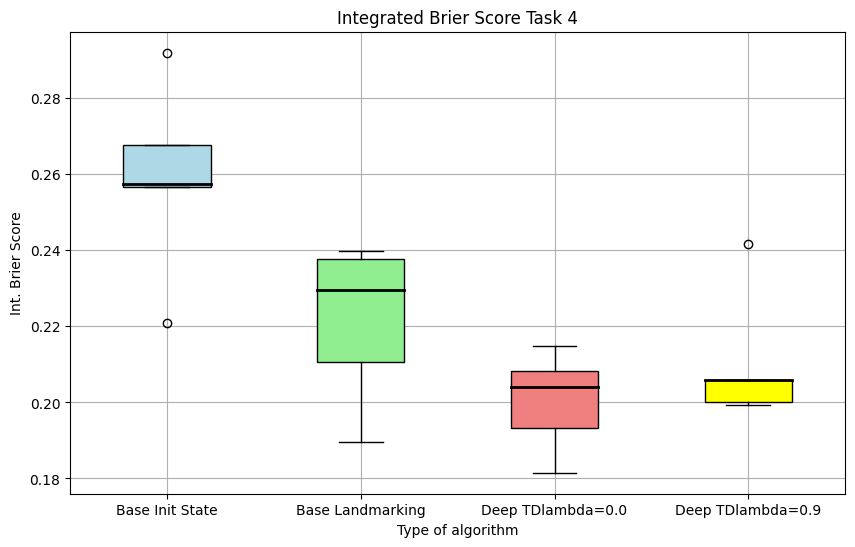

In [13]:


# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [1, 2, 3, 4]

medianprops = dict(color='black', linewidth=2)

# Create the boxplots
bs_is = ibs_is.reshape(-1)
bs_lm = ibs_lm.reshape(-1)
bs_a9 = bs_1.reshape(-1)
bs_a0 = bs_0.reshape(-1)
boxplot = ax.boxplot([bs_is, bs_lm, bs_a0, bs_a9], medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Base Init State', 'Base Landmarking', 'Deep TDlambda=0.0', 'Deep TDlambda=0.9'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Int. Brier Score")
ax.set_title("Integrated Brier Score Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
# plt.tight_layout()  # Ensures a tight layout
# plt.savefig("../../Figures/Int_brier_score_task_{}_transformer.pdf".format(task_id), format="pdf")

plt.show()


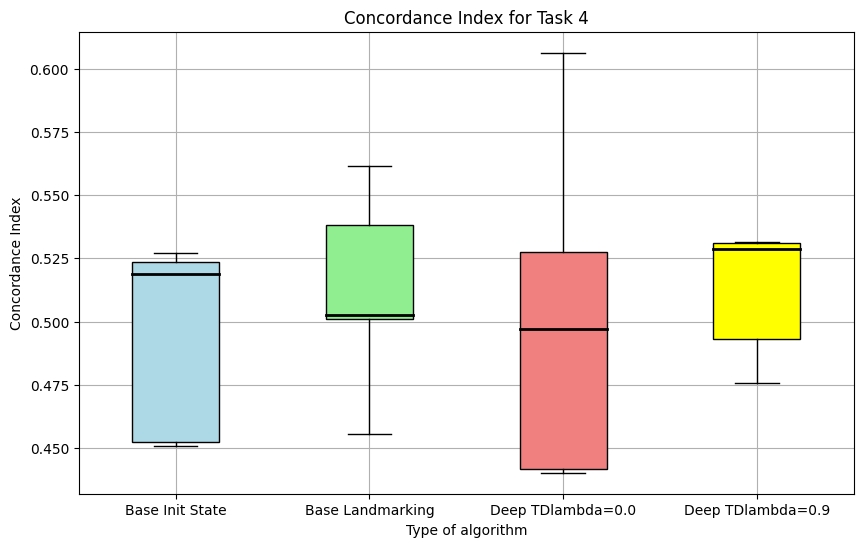

In [14]:


# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [1, 2, 3, 4]

medianprops = dict(color='black', linewidth=2)

# Create the boxplots
ci_is = ci_is.reshape(-1)
ci_lm = ci_lm.reshape(-1)
ci_a9 = ci_1.reshape(-1)
ci_a0 = ci_0.reshape(-1)
boxplot = ax.boxplot([ci_is, ci_lm, ci_a0, ci_a9], medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Base Init State', 'Base Landmarking', 'Deep TDlambda=0.0', 'Deep TDlambda=0.9'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Concordance Index")
ax.set_title("Concordance Index for Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
# plt.tight_layout()  # Ensures a tight layout
# plt.savefig("../../Figures/Concordance_idx_task_{}_transformer.pdf".format(task_id), format="pdf")

plt.show()


In [16]:
scores = model.scores(seqs, q=0.0)
concordance_index(scores, ts, cs)

0.6062667176155904

In [57]:
config['target_lr'] = 0.1
config['num_epochs'] = 200
config['learning_rate'] = .01

In [59]:
%%time

num_exps = 5
sizes = [.2]
size = sizes[0]
lambdas = [0.0, 0.1, 0.5, 0.9, 1.0]

bs_0 = np.zeros((num_exps, len(lambdas)))
ci_0 = np.zeros((num_exps, len(lambdas)))

for fold in range(num_exps):
    for i, lambda_ in enumerate(lambdas):
        config['lambda_'] = lambda_
        print(".", end="")

        # TCSR.
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_0[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        scores = model.scores(jnp.expand_dims(seqs[:,0], axis=1)).squeeze()
        ci_0[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:03<00:00,  1.61it/s]


.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:03<00:00,  1.62it/s]


.

...

.

100%|███████████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:14<00:00,  1.49it/s]


.

100%|███████████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:17<00:00,  1.46it/s]


CPU times: user 3h 3min 20s, sys: 11min 56s, total: 3h 15min 16s
Wall time: 53min 37s


In [15]:
bs_1

array([[0.17986894],
       [0.03354057],
       [0.03993847],
       [0.236086  ],
       [0.20756114]])

NameError: name 'lambdas' is not defined

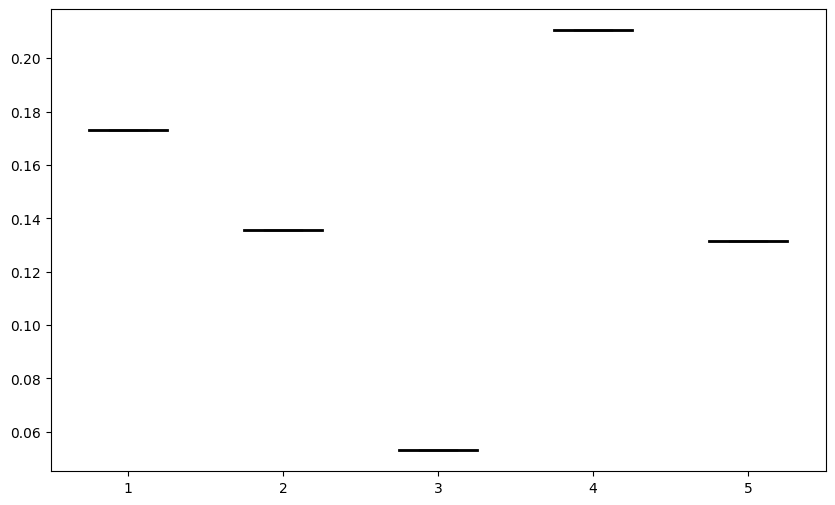

In [12]:


# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [i+1 for i in range(num_exps)]
medianprops = dict(color='black', linewidth=2)

# Create the boxplots
boxplot = ax.boxplot([bs_0[i] for i in range(num_exps)], medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels([f'Lambda={lambda_:.4f}' for lambda_ in lambdas])
ax.set_xlabel("Lambda value")
ax.set_ylabel("IBS")
ax.set_title("Int. Brier Score Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
# plt.tight_layout()  # Ensures a tight layout
# plt.savefig("../../Figures/Concordance_idx_task_{}.pdf".format(task_id), format="pdf")

plt.show()


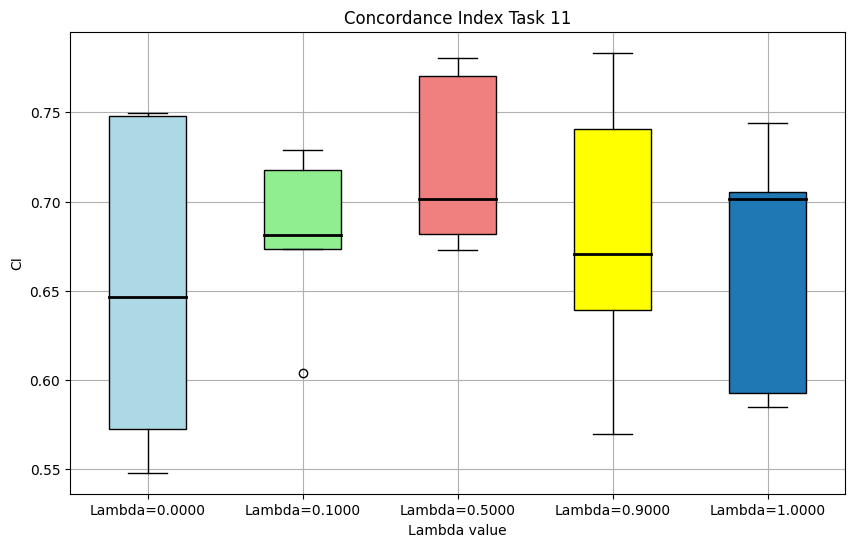

In [63]:


# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [i+1 for i in range(num_exps)]
medianprops = dict(color='black', linewidth=2)

# Create the boxplots
boxplot = ax.boxplot([ci_0[i] for i in range(num_exps)], medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels([f'Lambda={lambda_:.4f}' for lambda_ in lambdas])
ax.set_xlabel("Lambda value")
ax.set_ylabel("CI")
ax.set_title("Concordance Index Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
# plt.tight_layout()  # Ensures a tight layout
# plt.savefig("../../Figures/Concordance_idx_task_{}.pdf".format(task_id), format="pdf")

plt.show()


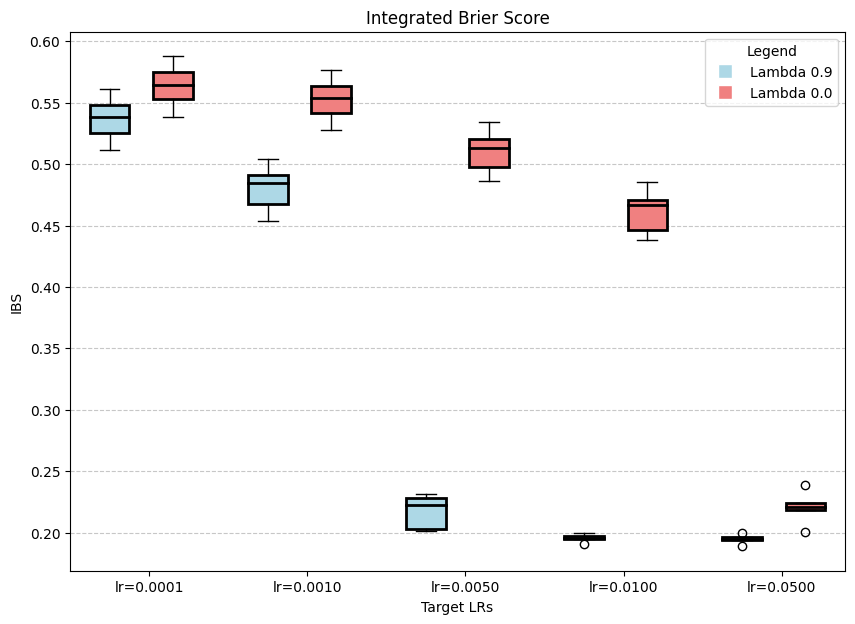

In [33]:
X = bs_1
Y = bs_0

# Create a list of positions for the boxplots
positions = np.arange(1, X.shape[1]*2, step=2)

# Set box colors
boxprops_X = dict(facecolor='lightblue', edgecolor='black', linewidth=2)
boxprops_Y = dict(facecolor='lightcoral', edgecolor='black', linewidth=2)

# Set mean line properties
medianprops = dict(color='black', linewidth=2)

# Set figure size
plt.figure(figsize=(10, 7))

# Plotting boxplots for X
plt.boxplot(X, positions=positions, labels=['' for i in range(len(tgt_lrs))], boxprops=boxprops_X, medianprops=medianprops, patch_artist=True)

# Plotting boxplots for Y
plt.boxplot(Y, positions=positions + 0.8, labels=['' for i in range(len(tgt_lrs))], boxprops=boxprops_Y, medianprops=medianprops, patch_artist=True)

# Create legend
legend_X = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightblue', markersize=10, label='Lambda 0.9')
legend_Y = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightcoral', markersize=10, label='Lambda 0.0')

plt.legend(handles=[legend_X, legend_Y], title='Legend')

# Customize the grid to have only horizontal lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set x-axis labels within boxplots
labels = [f'lr={lr:.4f}' for lr in tgt_lrs]
plt.xticks(positions+.5, labels, ha='center')


plt.xlabel('Target LRs')
plt.ylabel('IBS')
plt.title('Integrated Brier Score')

# Set y-axis limits
# plt.ylim(0.15, .25)

plt.show()


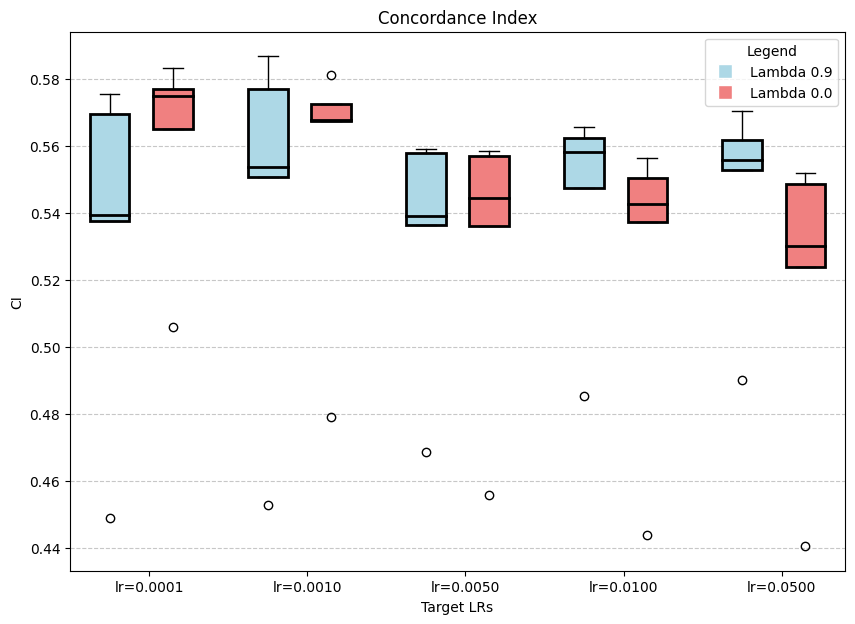

In [34]:
X = ci_1
Y = ci_0

# Create a list of positions for the boxplots
positions = np.arange(1, X.shape[1]*2, step=2)

# Set box colors
boxprops_X = dict(facecolor='lightblue', edgecolor='black', linewidth=2)
boxprops_Y = dict(facecolor='lightcoral', edgecolor='black', linewidth=2)

# Set mean line properties
medianprops = dict(color='black', linewidth=2)

# Set figure size
plt.figure(figsize=(10, 7))

# Plotting boxplots for X
plt.boxplot(X, positions=positions, labels=['' for i in range(len(tgt_lrs))], boxprops=boxprops_X, medianprops=medianprops, patch_artist=True)

# Plotting boxplots for Y
plt.boxplot(Y, positions=positions + 0.8, labels=['' for i in range(len(tgt_lrs))], boxprops=boxprops_Y, medianprops=medianprops, patch_artist=True)

# Create legend
legend_X = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightblue', markersize=10, label='Lambda 0.9')
legend_Y = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightcoral', markersize=10, label='Lambda 0.0')

plt.legend(handles=[legend_X, legend_Y], title='Legend')

# Customize the grid to have only horizontal lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set x-axis labels within boxplots
labels = [f'lr={lr:.4f}' for lr in tgt_lrs]
plt.xticks(positions+.5, labels, ha='center')


plt.xlabel('Target LRs')
plt.ylabel('CI')
plt.title('Concordance Index')

# Set y-axis limits
# plt.ylim(0.6, 0.8)

plt.show()


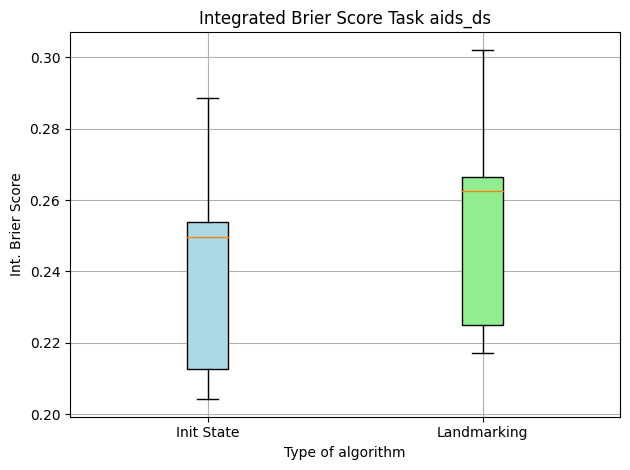

In [10]:

# Create a figure and axis
fig, ax = plt.subplots()

# Set the positions for the boxes
positions = [1, 2]

# Create the boxplots
x = res2_is.reshape(-1)
y = res2_lm.reshape(-1)
boxplot = ax.boxplot([x, y], positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Init State', 'Landmarking'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Int. Brier Score")
ax.set_title("Integrated Brier Score Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
plt.tight_layout()  # Ensures a tight layout
plt.savefig("../../Figures/Int_brier_score_task_{}.pdf".format(task_id), format="pdf")

plt.show()

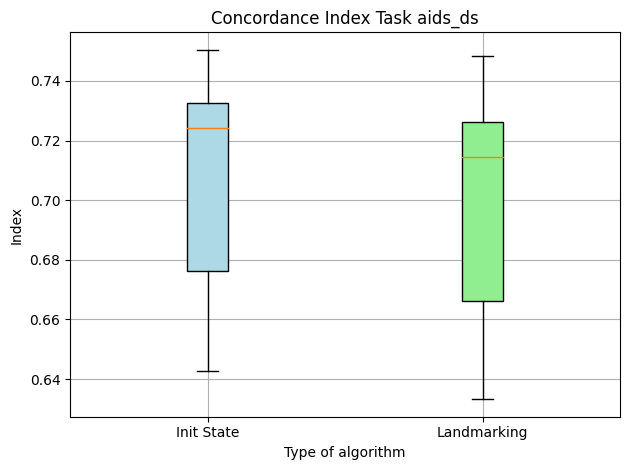

In [11]:

# Create a figure and axis
fig, ax = plt.subplots()

# Set the positions for the boxes
positions = [1, 2]

# Create the boxplots
x = res3_is.reshape(-1)
y = res3_lm.reshape(-1)
boxplot = ax.boxplot([x, y], positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Init State', 'Landmarking'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Index")
ax.set_title("Concordance Index Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
plt.tight_layout()  # Ensures a tight layout
plt.savefig("../../Figures/conc_idx_task_{}.pdf".format(task_id), format="pdf")

plt.show()


In [130]:
config['target_lr'] = 0.1
config['num_epochs'] = 100
config['learning_rate'] = .01

In [41]:
config['lambda_'] = 0.1

In [11]:
config['target_lr']

0.1

In [8]:
model = DeepLambdaSA(config, seed=2)

train_gen, test_gen = model.get_train_test(test_size=.2)
seqs = test_gen.X
ts = test_gen.ts
cs = test_gen.cs

In [9]:
losses = model.train(train_gen)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [03:44<00:00,  2.24s/it]


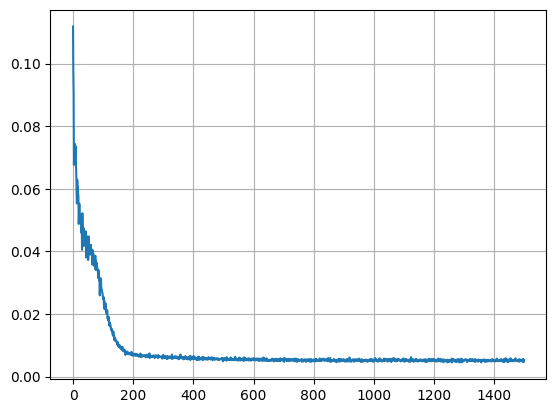

In [10]:
plt.plot(losses)
plt.grid()
plt.show()

In [141]:
len(losses)

1100

In [17]:
surv = model.survival_curve(seqs)
print('IBS ', model.integrated_brier_score(surv[:,0], ts, cs))

IBS  0.18150064


In [19]:
scores = model.scores(seqs, q=0)
print('CI: ', concordance_index(scores, ts, cs))

CI:  0.6062667176155904


In [20]:
train_gen.X.shape

(948, 100, 39)

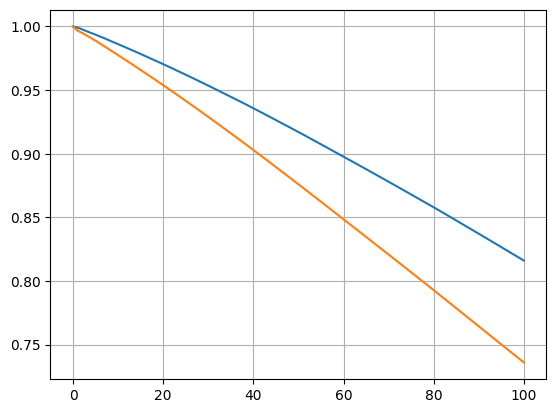

In [25]:
plt.plot(surv[:,0][0])
plt.plot(surv[:,0][10])
plt.grid()

In [35]:
scores[~cs]

Array([0.63159823, 0.66909593, 0.6867995 , 0.59731865, 0.53005314,
       0.6293069 , 0.68939716, 0.61776423, 0.7562973 , 0.81706053,
       0.6871769 , 0.6761294 , 0.8255155 , 0.81066537, 0.705775  ,
       0.6420748 , 0.60069877, 0.83174103, 0.6000927 , 0.50006056,
       0.6679537 , 0.71026385, 0.7308384 , 0.47087803, 0.55814016,
       0.5537901 , 0.54067993, 0.5978846 , 0.6841043 , 0.71256655,
       0.531995  , 0.45793074, 0.5909441 , 0.719419  , 0.5467581 ,
       0.8675272 , 0.49528924, 0.72086704, 0.7721184 , 0.4937198 ,
       0.61982816, 0.72392035, 0.78422064, 0.7866427 , 0.8326771 ,
       0.7515379 , 0.9135982 , 0.46039915, 0.23552413, 0.59043485,
       0.7231941 , 0.70126474, 0.74934155, 0.81755275, 0.7066024 ,
       0.63137454, 0.6078292 , 0.7485423 , 0.63794184, 0.68374133,
       0.6421315 , 0.7667595 , 0.72992563, 0.49241632, 0.80913645,
       0.7904509 ], dtype=float32)

In [36]:
ts[~cs]

array([41, 52, 57, 44, 40, 57, 54, 55,  5,  5,  5, 59,  5, 42, 59,  5,  4,
       54, 36,  5, 67,  5, 36,  5, 31, 51, 57,  5,  5,  4,  5, 60,  4,  5,
       61, 88, 38, 76,  5, 59, 26, 27, 46, 48,  5, 43,  5,  5, 49, 99,  5,
        5, 49, 49, 39,  4,  4,  5, 47,  5,  5, 44, 74,  5,  5,  4])

In [ ]:
tgt = lambda_ * h_tgt + (1 - lambda_) * s_tgt